
[![Electronic Profile](https://img.shields.io/badge/Electronic%20Profile-engineer--e-181717?logo=github)](https://github.com/engineer-e/) 
[![Work Profile](https://img.shields.io/badge/Work%20Profile-engineer--work-181717?logo=github)](https://github.com/engineer-work/) 
[![Instagram](https://img.shields.io/badge/Instagram-gobalkrishnan.engineer-E4405F?logo=instagram&logoColor=white)](https://www.instagram.com/gobalkrishnan.engineer/)

# 3. The vec3 Class

## 3.1. Color Utility Functions


This is the **color utility layer** in ray tracing.

The idea:

Before:

```cpp
std::cout << ir << ' ' << ig << ' ' << ib << '\n';
```

Now:

```cpp
write_color(std::cout, pixel_color);
```

So color writing is separated into its own function.

This makes code cleaner.

---

# Python Version

---

## `vec3.py`

```python
import math


class Vec3:
    def __init__(self, x=0, y=0, z=0):
        self.e = [x, y, z]

    @property
    def x(self):
        return self.e[0]

    @property
    def y(self):
        return self.e[1]

    @property
    def z(self):
        return self.e[2]


Point3 = Vec3
Color = Vec3
```

---

## `color.py`

```python
from vec3 import Color


def write_color(pixel_color):
    r = pixel_color.x
    g = pixel_color.y
    b = pixel_color.z

    # Translate [0,1] → [0,255]
    rbyte = int(255.999 * r)
    gbyte = int(255.999 * g)
    bbyte = int(255.999 * b)

    return f"{rbyte} {gbyte} {bbyte}\n"
```

---

## `main.py`

```python
from vec3 import Color
from color import write_color


# Image
image_width = 256
image_height = 256


# Render
with open("image.ppm", "w") as f:
    f.write(f"P3\n{image_width} {image_height}\n255\n")

    for j in range(image_height):
        print(f"\rScanlines remaining: {image_height-j}", end="")

        for i in range(image_width):

            pixel_color = Color(
                i / (image_width - 1),
                j / (image_height - 1),
                0
            )

            f.write(write_color(pixel_color))

print("\nDone.")
```

---


Yes. Here is the **Learning Notes** rewritten fully in **table format**.

# Learning Notes Table

| Topic                       | Formula                                                 | Meaning                               | Purpose                                  |
| --------------------------- | ------------------------------------------------------- | ------------------------------------- | ---------------------------------------- |
| **Color Alias**             | $Color \equiv Vec3$                                     | Color is just another name for `Vec3` | Makes code easier to read                |
| **Point Alias**             | $Point3 \equiv Vec3$                                    | Point is also `Vec3`                  | Gives geometric meaning                  |
| **Color Representation**    | $C=(r,g,b)$                                             | Stores red, green, blue               | Represents pixel color                   |
| **Color Range**             | $r,g,b \in [0,1]$                                       | Floating-point intensity values       | Used for calculations                    |
| **PPM Byte Range**          | $R,G,B \in [0,255]$                                     | Integer color output                  | Required by PPM format                   |
| **Float → Byte Conversion** | $byte = 255.999 \cdot component$                        | Converts normalized color to integer  | Writes image data correctly              |
| **Red Gradient**            | $r=\frac{i}{width-1}$                                   | Horizontal color change               | Creates left-to-right red gradient       |
| **Green Gradient**          | $g=\frac{j}{height-1}$                                  | Vertical color change                 | Creates bottom-to-top green gradient     |
| **Blue Constant**           | $b=0$                                                   | Blue channel fixed                    | Keeps blue absent                        |
| **Pixel Color Formula**     | $C=\left(\frac{i}{width-1},\frac{j}{height-1},0\right)$ | Combines all channels                 | Defines final pixel color                |
| **Red Byte Output**         | $R=255.999r$                                            | Converts red to byte                  | Output for file                          |
| **Green Byte Output**       | $G=255.999g$                                            | Converts green to byte                | Output for file                          |
| **Blue Byte Output**        | $B=255.999b$                                            | Converts blue to byte                 | Output for file                          |
| **Normalization Formula**   | $x'=\frac{x-x_{min}}{x_{max}-x_{min}}$                  | General scaling formula               | Maps values into $[0,1]$                 |
| **This Case Normalization** | $x'=\frac{x}{x_{max}}$                                  | Since $x_{min}=0$                     | Simplifies pixel normalization           |
| **Rendering Pipeline**      | $(i,j)\to(r,g,b)\to(R,G,B)\to PPM$                      | Full pixel generation process         | Creates final image                      |
| **write_color() Function**  | $write_color(C)\to(R,G,B)$                              | Converts and writes color             | Separates output logic from render logic |

---

# File Responsibility Table

| File       | Role             | Mathematical Job             |
| ---------- | ---------------- | ---------------------------- |
| `vec3.py`  | Vector storage   | Holds $(x,y,z)$ or $(r,g,b)$ |
| `color.py` | Color conversion | Maps $[0,1] \to [0,255]$     |
| `main.py`  | Rendering loop   | Generates every pixel        |

---

# Pixel Example Table

Suppose:

$$
i=128,;j=64,;width=256,;height=256
$$

| Step       | Formula              | Result  |
| ---------- | -------------------- | ------- |
| Red        | $r=\frac{128}{255}$  | $0.502$ |
| Green      | $g=\frac{64}{255}$   | $0.251$ |
| Blue       | $b=0$                | $0$     |
| Red Byte   | $255.999\times0.502$ | $128$   |
| Green Byte | $255.999\times0.251$ | $64$    |
| Blue Byte  | $255.999\times0$     | $0$     |

Final output:

$$
(128,64,0)
$$



# Color Components

A pixel color:

$$
C=(r,g,b)
$$

Where:

| Component | Range   |
| --------- | ------- |
| $r$       | $[0,1]$ |
| $g$       | $[0,1]$ |
| $b$       | $[0,1]$ |

Example:

$$
(0.5,0.2,1.0)
$$

means:

* 50% red
* 20% green
* 100% blue

---

# Why convert to bytes?

PPM uses:

$$
[0,255]
$$

But ray tracer computes:

$$
[0,1]
$$

Need mapping.

Formula:

$$
byte = 255.999 \cdot component
$$

---

# Conversion Table

| Float Value | Formula             | Byte Output |
| ----------- | ------------------- | ----------- |
| $0.0$       | $255.999 \cdot 0.0$ | 0           |
| $0.5$       | $255.999 \cdot 0.5$ | 127         |
| $1.0$       | $255.999 \cdot 1.0$ | 255         |

---

# Full Pixel Formula

For each pixel:

Red:

$$
r = \frac{i}{width-1}
$$

Green:

$$
g = \frac{j}{height-1}
$$

Blue:

$$
b = 0
$$

Color:

$$
C=(r,g,b)
$$

Byte conversion:

$$
R=255.999r
$$

$$
G=255.999g
$$

$$
B=255.999b
$$

Output:

$$
(R,G,B)
$$

---

# Why this formula?

| Formula              | Purpose             |
| -------------------- | ------------------- |
| $\frac{i}{width-1}$  | horizontal gradient |
| $\frac{j}{height-1}$ | vertical gradient   |

This normalizes:

$$
i \in [0,width-1]
$$

to:

$$
r \in [0,1]
$$

General normalization:

$$
x'=\frac{x-x_{min}}{x_{max}-x_{min}}
$$

Here:

$$
x_{min}=0
$$

So:

$$
x'=\frac{x}{x_{max}}
$$

---

# Flow of Rendering

| Step | Action                   |
| ---- | ------------------------ |
| 1    | Loop through each pixel  |
| 2    | Compute normalized color |
| 3    | Convert float → byte     |
| 4    | Write into PPM file      |

Pipeline:

$$
(i,j)
\to
(r,g,b)
\to
(R,G,B)
\to
PPM
$$

---

# Why `write_color()`?

Without it:

everything in main.

With it:

main only renders.

Utility handles output.

Separation:

| File       | Job          |
| ---------- | ------------ |
| `vec3.py`  | math         |
| `color.py` | color output |
| `main.py`  | rendering    |

This is cleaner architecture.


# Vec3 

In [1]:
import math


class Vec3:
    def __init__(self, x=0, y=0, z=0):
        self.e = [x, y, z]

    # Accessors
    @property
    def x(self):
        return self.e[0]

    @property
    def y(self):
        return self.e[1]

    @property
    def z(self):
        return self.e[2]

    # Negative vector
    def __neg__(self):
        return Vec3(-self.e[0], -self.e[1], -self.e[2])

    # Index access
    def __getitem__(self, i):
        return self.e[i]

    def __setitem__(self, i, value):
        self.e[i] = value

    # Addition
    def __add__(self, other):
        return Vec3(
            self.e[0] + other.e[0],
            self.e[1] + other.e[1],
            self.e[2] + other.e[2]
        )

    # Subtraction
    def __sub__(self, other):
        return Vec3(
            self.e[0] - other.e[0],
            self.e[1] - other.e[1],
            self.e[2] - other.e[2]
        )

    # Multiplication
    def __mul__(self, t):
        if isinstance(t, Vec3):
            return Vec3(
                self.e[0] * t.e[0],
                self.e[1] * t.e[1],
                self.e[2] * t.e[2]
            )
        return Vec3(
            self.e[0] * t,
            self.e[1] * t,
            self.e[2] * t
        )

    # Division
    def __truediv__(self, t):
        return self * (1 / t)

    # Length squared
    def length_squared(self):
        return (
            self.e[0]**2 +
            self.e[1]**2 +
            self.e[2]**2
        )

    # Length
    def length(self):
        return math.sqrt(self.length_squared())

    def __str__(self):
        return f"{self.e[0]} {self.e[1]} {self.e[2]}"


# Dot product
def dot(u, v):
    return u.e[0]*v.e[0] + u.e[1]*v.e[1] + u.e[2]*v.e[2]


# Cross product
def cross(u, v):
    return Vec3(
        u.e[1]*v.e[2] - u.e[2]*v.e[1],
        u.e[2]*v.e[0] - u.e[0]*v.e[2],
        u.e[0]*v.e[1] - u.e[1]*v.e[0]
    )


# Unit vector
def unit_vector(v):
    return v / v.length()


Point3 = Vec3
Color = Vec3 

# Color

In [8]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")



In [9]:
from util.vec3 import Vec3
from util.vec3 import Color


def write_color(pixel_color):
    r = pixel_color.x
    g = pixel_color.y
    b = pixel_color.z

    # Translate [0,1] → [0,255]
    rbyte = int(255.999 * r)
    gbyte = int(255.999 * g)
    bbyte = int(255.999 * b)

    return f"{rbyte} {gbyte} {bbyte}\n"

In [18]:
# Base Code
from util.vec3 import Vec3
from util.vec3 import Color
from util.color import write_color
from tqdm import tqdm



# Image
image_width = 1980
image_height = 1080


# Render
with open("image.ppm", "w") as f:
    f.write(f"P3\n{image_width} {image_height}\n255\n")

    for j in tqdm(range(image_height), desc="Rendering"):
        #print(f"\rScanlines remaining: {image_height-j}", end="")

        for i in range(image_width):

            pixel_color = Color(
                0,
                i / (image_width - 1),
                j / (image_height - 1),
                
            )

            f.write(write_color(pixel_color))

print("\nDone.")

Rendering: 100%|██████████| 1080/1080 [00:03<00:00, 285.67it/s]


Done.


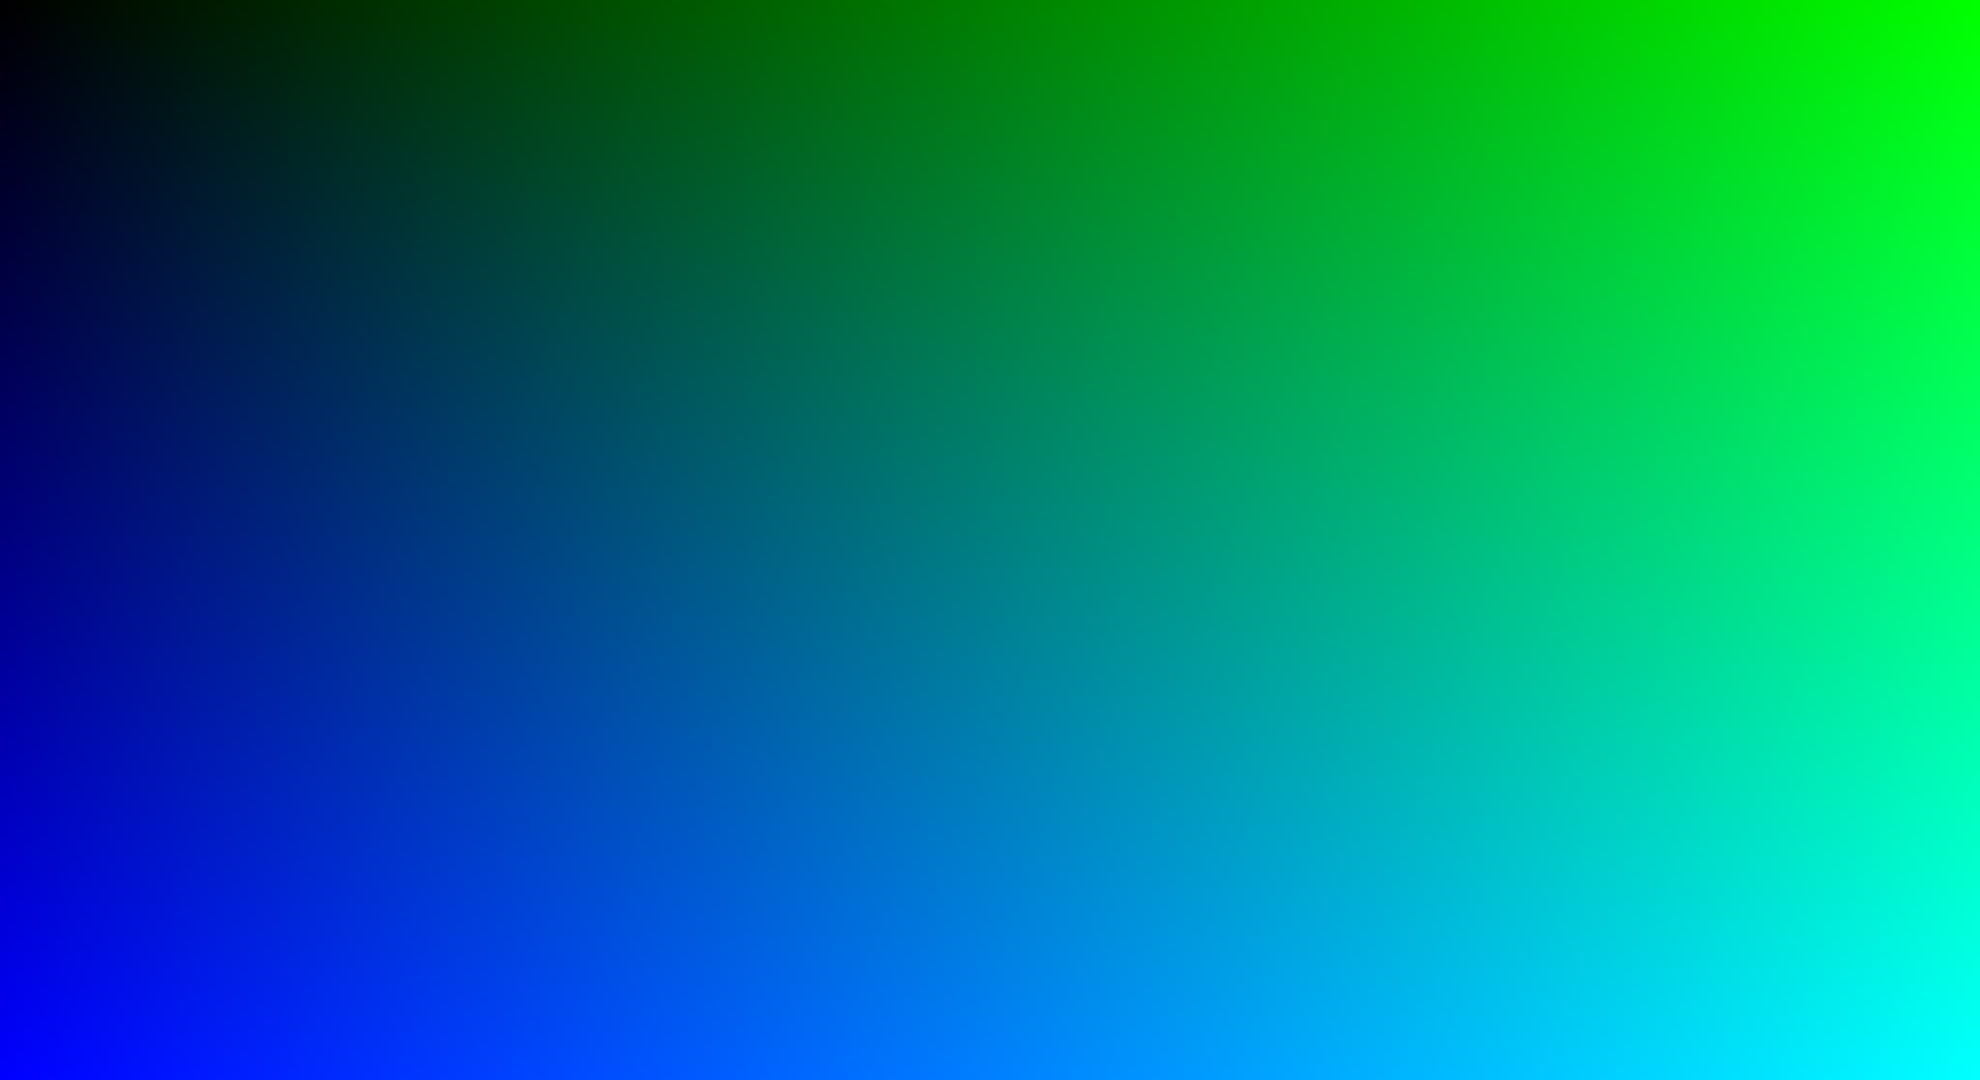

In [19]:
from util.image_viewer import image_viewer
from util.scale_image import scale

a = image_viewer("image.ppm")
a